In [177]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

In [178]:
def get_epoch_list(num_epochs):
    return np.array([i for i in range(num_epochs)])
def get_frz_nofrz_samples(start_frz, num_epochs):
    frz_nofrz = np.array([0 for _ in range(num_epochs)])
    start_frz_index = start_frz - 1
    frz_nofrz[start_frz_index:] = 1
    return frz_nofrz
def get_weights_based_on_distance_from_frz_region(start_frz, end_frz, num_epochs, sample_weight_function=None, clip_val=None):
    weights_based_on_distance_from_frz_region = []
    weights_based_on_distance_from_nofrz_region = []
    
    # Loop for processing distance from frozen region
    for i in range(1, num_epochs+1):
        # Penalties based on distance from left boundary
        if i < start_frz:
            distance_from_boundary = start_frz - i
            length_of_boundary = start_frz
        # Penalties baed on distance from right boundary
        elif i > end_frz:
            distance_from_boundary = i - end_frz
            length_of_boundary = num_epochs - i
        else:
            distance_from_boundary = 0
            length_of_boundary = 0
        
        if distance_from_boundary == 0:
            # Indicates correct prediction region, no additional penalty
            weights_based_on_distance_from_frz_region.append(0)
        else:
            normalized_weights = distance_from_boundary / length_of_boundary      
            weights_based_on_distance_from_frz_region.append(normalized_weights)
    
    # Loop for processing distance from non-frozen region
    for i in range(1, num_epochs+1):
        if i < start_frz:
            distance_from_boundary = 0
            length_of_boundary = 0
        else:
            distance_from_boundary = i - start_frz
            length_of_boundary = end_frz - start_frz
        
        if distance_from_boundary == 0:
            weights_based_on_distance_from_nofrz_region.append(0)
        else:
            normalized_weights = distance_from_boundary / length_of_boundary
            weights_based_on_distance_from_nofrz_region.append(normalized_weights)
    
    if sample_weight_function == "quad":
        weights_based_on_distance_from_frz_region = [weight ** 2 for weight in weights_based_on_distance_from_frz_region]
        weights_based_on_distance_from_nofrz_region = [weight ** 2 for weight in weights_based_on_distance_from_nofrz_region]
    elif sample_weight_function == "exp":
        weights_based_on_distance_from_frz_region = [torch.exp(torch.tensor(weight))  if weight != 0 else 0 for weight in weights_based_on_distance_from_frz_region]
        weights_based_on_distance_from_nofrz_region = [torch.exp(torch.tensor(weight)) if weight != 0 else 0 for weight in weights_based_on_distance_from_nofrz_region]
        
        max_frz_region_weight = max(weights_based_on_distance_from_frz_region)
        max_no_frz_region_weight = max(weights_based_on_distance_from_nofrz_region)
        weights_based_on_distance_from_frz_region = [item / max_frz_region_weight for item in weights_based_on_distance_from_frz_region]
        weights_based_on_distance_from_nofrz_region = [item / max_no_frz_region_weight for item in weights_based_on_distance_from_nofrz_region]
    if clip_val:
        weights_based_on_distance_from_frz_region[:start_frz] = [clip_val if item < clip_val else item for item in weights_based_on_distance_from_frz_region[:start_frz]]
        weights_based_on_distance_from_nofrz_region[start_frz:end_frz] = [clip_val if item < clip_val else item for item in weights_based_on_distance_from_nofrz_region[start_frz:end_frz]]
    return weights_based_on_distance_from_frz_region, weights_based_on_distance_from_nofrz_region

In [179]:
num_epochs = 160
start_frz = 140
end_frz = 160

In [180]:
epoch_list = get_epoch_list(num_epochs)

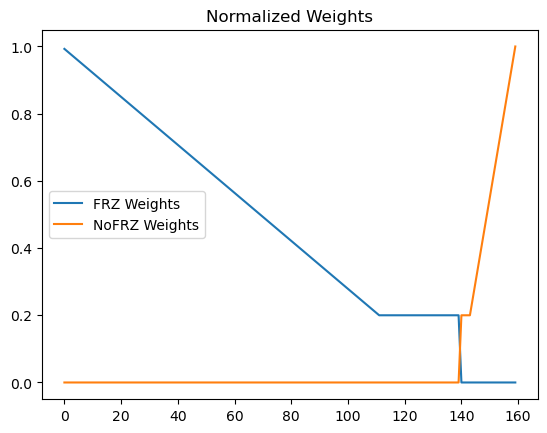

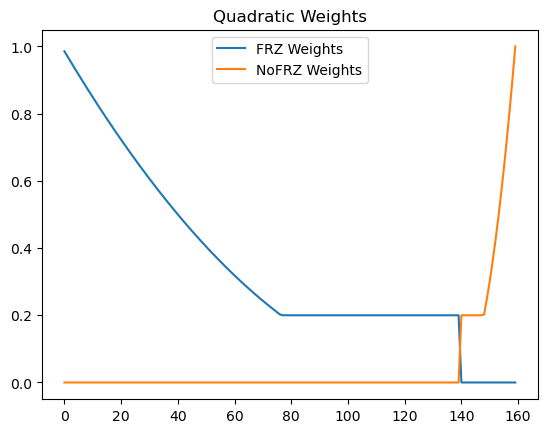

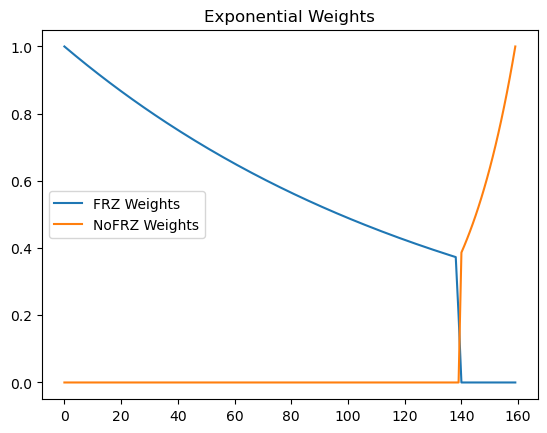

In [181]:
weights_norm_frz, weights_norm_nofrz = get_weights_based_on_distance_from_frz_region(start_frz, end_frz, num_epochs, clip_val=0.2)
weights_quad_frz, weights_quad_nofrz = get_weights_based_on_distance_from_frz_region(start_frz, end_frz, num_epochs, sample_weight_function="quad", clip_val=0.2)
weights_exp_frz, weights_exp_nofrz = get_weights_based_on_distance_from_frz_region(start_frz, end_frz, num_epochs, sample_weight_function="exp", clip_val=0.2)
plt.title("Normalized Weights")
plt.plot(epoch_list, weights_norm_frz, label="FRZ Weights")
plt.plot(epoch_list, weights_norm_nofrz, label="NoFRZ Weights")
plt.legend()
plt.show()
plt.title("Quadratic Weights")
plt.plot(epoch_list, weights_quad_frz, label="FRZ Weights")
plt.plot(epoch_list, weights_quad_nofrz, label="NoFRZ Weights")
plt.legend()
plt.show()
plt.title("Exponential Weights")
plt.plot(epoch_list, weights_exp_frz, label="FRZ Weights")
plt.plot(epoch_list, weights_exp_nofrz, label="NoFRZ Weights")
plt.legend()
plt.show()

In [201]:
# Create a list of 0s and 1s
def use_sampled_weights_to_compute_error_rate(weights_frz, weights_no_frz, actual_labels, frz_preds):
    L = 0
    for weight_frz, weight_no_frz, actual_label, frz_pred in zip(weights_frz, weights_no_frz, actual_labels, frz_preds):
        if actual_label != frz_pred:
            if frz_pred == 0:
                # Use weights from no_frz
                L += weight_no_frz
            else:
                # Use weights from frz
                L += weight_frz
    L /= sum(weights_no_frz) + sum(weights_frz)
    return L

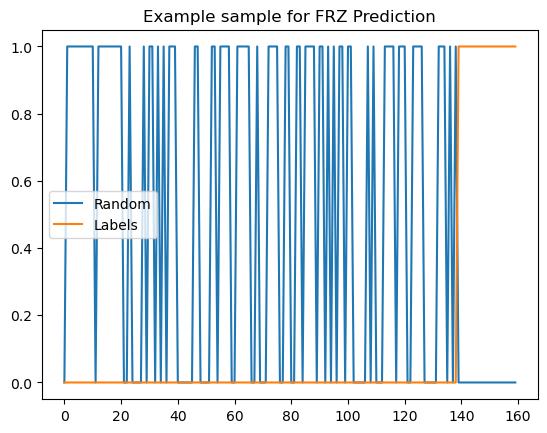

In [212]:
example_frz_prediction = get_frz_nofrz_samples(start_frz, num_epochs)
random_frz_prediction = np.array([random.randint(0, 1) for _ in range(num_epochs)])
random_frz_prediction[140:] = 0
plt.title("Example sample for FRZ Prediction")
plt.plot(epoch_list, random_frz_prediction, label="Random")
plt.plot(epoch_list, example_frz_prediction, label="Labels")
plt.legend()
plt.show()

In [213]:
# Use linear normalized weights
error_rate_normalized_weights = use_sampled_weights_to_compute_error_rate(weights_norm_frz, weights_norm_nofrz, example_frz_prediction, random_frz_prediction)
print(f"Regular normalized weights for error rate: {error_rate_normalized_weights}")
# Use quadratic normalized weights
error_rate_quad_weights = use_sampled_weights_to_compute_error_rate(weights_quad_frz, weights_quad_nofrz, example_frz_prediction, random_frz_prediction)
print(f"Quadratic normalized weights for error rate: {error_rate_quad_weights}")
# Use exponential normalized weights
error_rate_exp_weights = use_sampled_weights_to_compute_error_rate(weights_exp_frz, weights_exp_nofrz, example_frz_prediction, random_frz_prediction)
print(f"Exponential normalized weights for error rate: {error_rate_exp_weights}")

Regular normalized weights for error rate: 0.6535885989010991
Quadratic normalized weights for error rate: 0.6671031888023133
Exponential normalized weights for error rate: 0.6433590650558472
